Dataset loaded successfully from local file!

Columns in dataset: ['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare']

First 5 rows:


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500



=== DATA CLEANING ===
Missing values before cleaning:
Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64

Missing values after cleaning:
Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
FamilySize                 0
dtype: int64

=== BASIC ANALYSIS ===
Dataset shape: (887, 9)

Basic statistics:


,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,FamilySize
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000,887.000000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542,0.908681
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204,1.615949
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000,0.000000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500,0.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420,0.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750,1.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920,10.000000



Survival rate by passenger class:


...


Survival rate by sex:


Sex
female    0.742038
male      0.190227
Name: Survived, dtype: float64


Survival rate by family size:


FamilySize
0     0.305816
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64


=== DATA VISUALIZATION ===


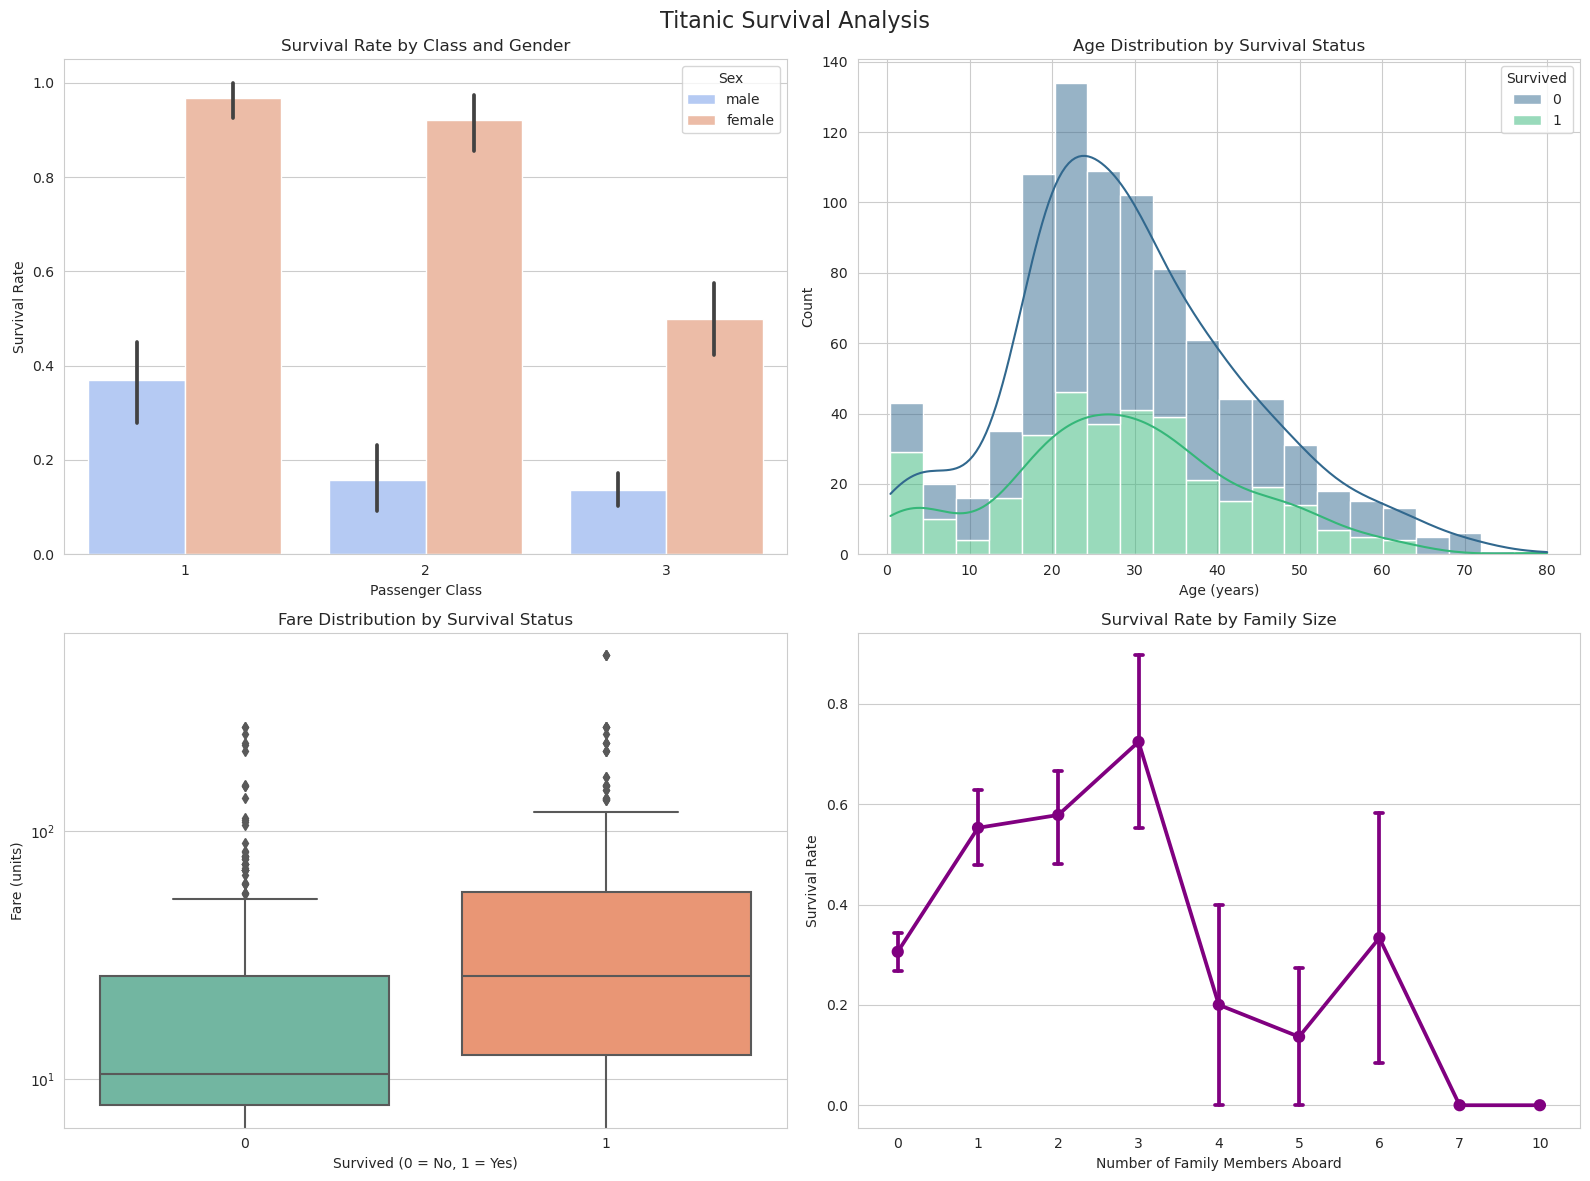


=== ADVANCED ANALYSIS ===

Survival rate by age group:


AgeGroup
Child          0.544304
Teen           0.402299
Young Adult    0.331476
Adult          0.424138
Senior         0.305556
Name: Survived, dtype: float64

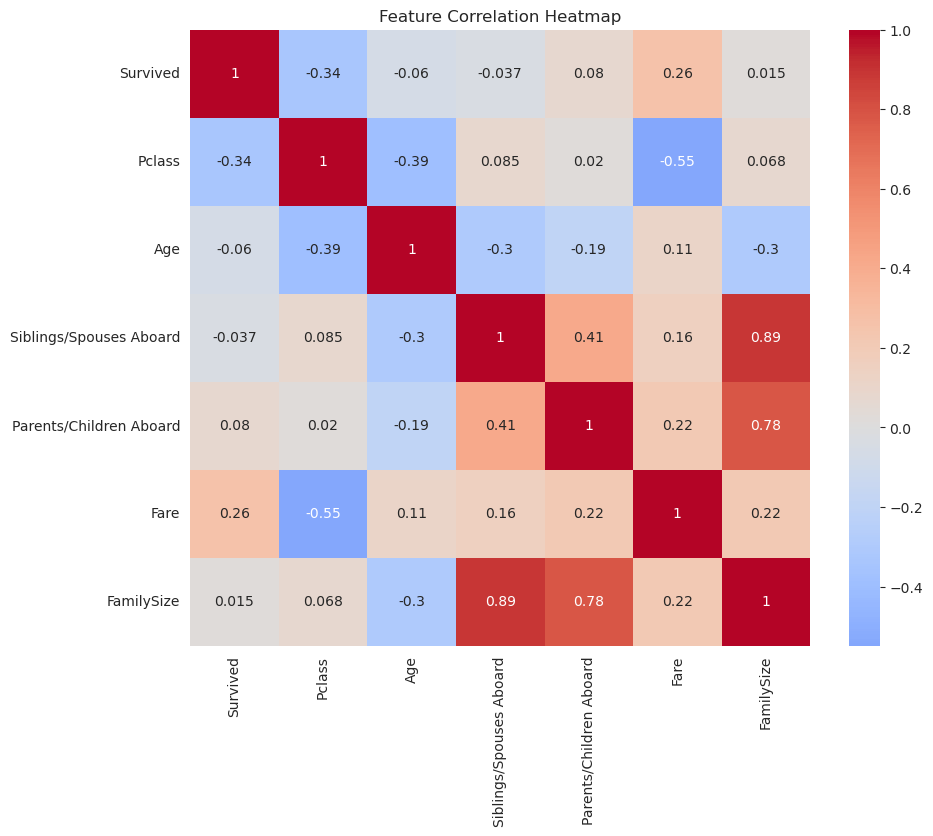


=== KEY FINDINGS ===
Overall survival rate: 38.56%
Highest survival rate by class: 1st class (62.96%)
Highest survival rate by age group: Children (54.43%)
Female survival rate: 74.20%
Male survival rate: 19.02%


In [13]:
# TASK 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 1. Load the dataset from local file
try:
    titanic_df = pd.read_csv('titanic.csv')
    print("Dataset loaded successfully from local file!")
except FileNotFoundError:
    print("Error: titanic.csv file not found in current directory.")
    print("Please ensure the file is in your working directory.")
    # List files in current directory to help debugging
    import os
    print("\nFiles in current directory:", os.listdir())

# Display column names and first few rows
print("\nColumns in dataset:", titanic_df.columns.tolist())
print("\nFirst 5 rows:")
display(titanic_df.head())

# 2. Data Cleaning
print("\n=== DATA CLEANING ===")
print("Missing values before cleaning:")
print(titanic_df.isnull().sum())

# Fill missing ages with median
titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)

# Create FamilySize feature
titanic_df['FamilySize'] = titanic_df['Siblings/Spouses Aboard'] + titanic_df['Parents/Children Aboard']

print("\nMissing values after cleaning:")
print(titanic_df.isnull().sum())

# 3. Basic Data Analysis
print("\n=== BASIC ANALYSIS ===")
print("Dataset shape:", titanic_df.shape)
print("\nBasic statistics:")
display(titanic_df.describe())

# Survival rates by different factors
print("\nSurvival rate by passenger class:")
display(titanic_df.groupby('Pclass')['Survived'].mean())

print("\nSurvival rate by sex:")
display(titanic_df.groupby('Sex')['Survived'].mean())

print("\nSurvival rate by family size:")
display(titanic_df.groupby('FamilySize')['Survived'].mean())

# 4. Data Visualization
print("\n=== DATA VISUALIZATION ===")
plt.figure(figsize=(16, 12))
plt.suptitle('Titanic Survival Analysis', fontsize=16)

# Plot 1: Survival by class and sex
plt.subplot(2, 2, 1)
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df, palette='coolwarm')
plt.title('Survival Rate by Class and Gender')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')

# Plot 2: Age distribution by survival
plt.subplot(2, 2, 2)
sns.histplot(data=titanic_df, x='Age', hue='Survived', bins=20, 
             kde=True, multiple='stack', palette='viridis')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age (years)')
plt.ylabel('Count')

# Plot 3: Fare distribution by survival
plt.subplot(2, 2, 3)
sns.boxplot(x='Survived', y='Fare', data=titanic_df, palette='Set2')
plt.title('Fare Distribution by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare (units)')
plt.yscale('log')  # Using log scale due to right-skewed fare distribution

# Plot 4: Survival by family size
plt.subplot(2, 2, 4)
sns.pointplot(x='FamilySize', y='Survived', data=titanic_df, 
              capsize=0.1, color='purple')
plt.title('Survival Rate by Family Size')
plt.xlabel('Number of Family Members Aboard')
plt.ylabel('Survival Rate')

plt.tight_layout()
plt.show()

# 5. Advanced Analysis
print("\n=== ADVANCED ANALYSIS ===")
# Age groups analysis
titanic_df['AgeGroup'] = pd.cut(titanic_df['Age'], 
                               bins=[0, 12, 18, 30, 50, 100],
                               labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

print("\nSurvival rate by age group:")
age_group_survival = titanic_df.groupby('AgeGroup')['Survived'].mean()
display(age_group_survival)

# Interactive correlation heatmap
plt.figure(figsize=(10, 8))
numeric_df = titanic_df[['Survived', 'Pclass', 'Age', 'Siblings/Spouses Aboard', 
                        'Parents/Children Aboard', 'Fare', 'FamilySize']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

# 6. Key Findings Summary
print("\n=== KEY FINDINGS ===")
print(f"Overall survival rate: {titanic_df['Survived'].mean():.2%}")
print(f"Highest survival rate by class: 1st class ({titanic_df[titanic_df['Pclass']==1]['Survived'].mean():.2%})")
print(f"Highest survival rate by age group: Children ({age_group_survival['Child']:.2%})")
print(f"Female survival rate: {titanic_df[titanic_df['Sex']=='female']['Survived'].mean():.2%}")
print(f"Male survival rate: {titanic_df[titanic_df['Sex']=='male']['Survived'].mean():.2%}")

In [9]:
# TASK 2

# 1. Compute basic statistics for numerical columns
print("=== BASIC STATISTICS ===")
numerical_cols = ['Survived', 'Pclass', 'Age', 'Siblings/Spouses Aboard', 
                 'Parents/Children Aboard', 'Fare', 'FamilySize']
display(titanic_df[numerical_cols].describe())

# 2. Group by categorical columns and compute means
print("\n=== GROUP ANALYSIS ===")

# Group by Sex and calculate mean survival and fare
print("\nMean survival and fare by sex:")
sex_groups = titanic_df.groupby('Sex').agg({
    'Survived': 'mean',
    'Fare': 'mean',
    'Age': 'median'
})
display(sex_groups)

# Group by Pclass and calculate mean survival and age
print("\nMean survival and age by passenger class:")
class_groups = titanic_df.groupby('Pclass').agg({
    'Survived': 'mean',
    'Fare': 'median',
    'FamilySize': 'mean'
})
display(class_groups)

# 3. Identify interesting patterns
print("\n=== KEY FINDINGS ===")
print("1. Survival rate disparity: Females had", 
      f"{sex_groups.loc['female', 'Survived']:.1%} survival vs males",
      f"{sex_groups.loc['male', 'Survived']:.1%}")

print("2. Class impact: 1st class passengers had", 
      f"{class_groups.loc[1, 'Survived']:.1%} survival vs 3rd class",
      f"{class_groups.loc[3, 'Survived']:.1%}")

print("3. Fare difference: 1st class paid median fare of",
      f"${class_groups.loc[1, 'Fare']:.2f} vs 3rd class",
      f"${class_groups.loc[3, 'Fare']:.2f}")

print("4. Family size: 2nd class had largest average family size of",
      f"{class_groups.loc[2, 'FamilySize']:.2f} members")

=== BASIC STATISTICS ===


,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,FamilySize
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000,887.000000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542,0.908681
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204,1.615949
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000,0.000000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500,0.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420,0.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750,1.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920,10.000000



=== GROUP ANALYSIS ===

Mean survival and fare by sex:


,Survived,Fare,Age
Sex,,,
female,0.742038,44.479818,27.0
male,0.190227,25.633935,28.0



Mean survival and age by passenger class:


,Survived,Fare,FamilySize
Pclass,,,
1,0.629630,60.2875,0.773148
2,0.472826,14.2500,0.782609
3,0.244353,8.0500,1.016427



=== KEY FINDINGS ===
1. Survival rate disparity: Females had 74.2% survival vs males 19.0%
2. Class impact: 1st class passengers had 63.0% survival vs 3rd class 24.4%
3. Fare difference: 1st class paid median fare of $60.29 vs 3rd class $8.05
4. Family size: 2nd class had largest average family size of 0.78 members


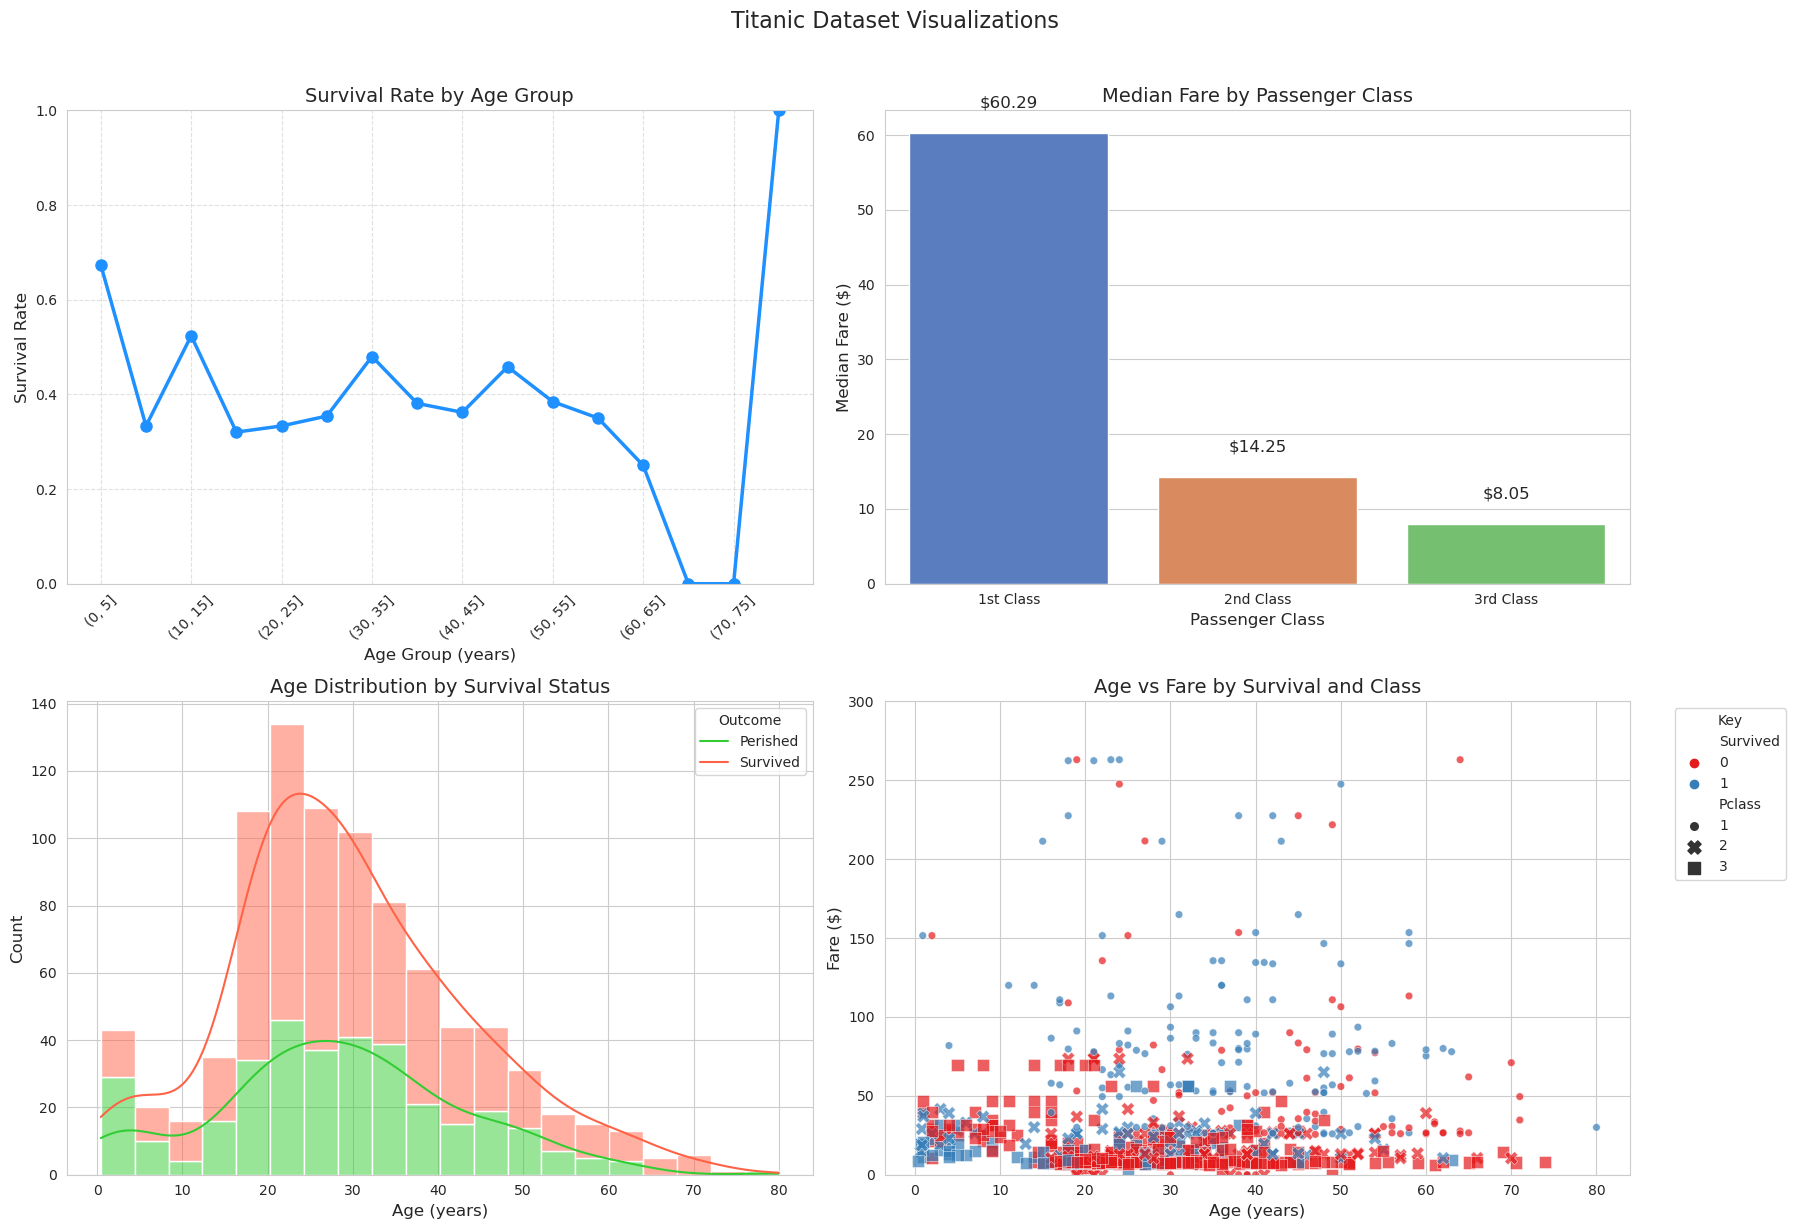

In [18]:
# TASK 3

# Task 3: Data Visualization (Updated)
plt.figure(figsize=(18, 12))
plt.suptitle('Titanic Dataset Visualizations', fontsize=16, y=1.02)

# 1. Line Chart: Survival Rate by Age Group (Trend Over Time Proxy)
plt.subplot(2, 2, 1)
age_bins = range(0, 85, 5)
age_survival = titanic_df.groupby(pd.cut(titanic_df['Age'], bins=age_bins))['Survived'].mean()
age_survival.plot(kind='line', marker='o', color='dodgerblue', linewidth=2.5, markersize=8)
plt.title('Survival Rate by Age Group', fontsize=14)
plt.xlabel('Age Group (years)', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1)

# 2. Bar Chart: Average Fare by Passenger Class (Fixed ci parameter)
plt.subplot(2, 2, 2)
fare_by_class = titanic_df.groupby('Pclass')['Fare'].median()
ax = sns.barplot(x='Pclass', y='Fare', data=titanic_df, estimator=np.median,
                errorbar=None, palette='muted')
plt.title('Median Fare by Passenger Class', fontsize=14)
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Median Fare ($)', fontsize=12)
plt.xticks([0, 1, 2], ['1st Class', '2nd Class', '3rd Class'])

# Add value labels on bars
for i, v in enumerate(fare_by_class):
    ax.text(i, v+3, f"${v:.2f}", ha='center', va='bottom', fontsize=12)

# 3. Histogram: Age Distribution by Survival Status
plt.subplot(2, 2, 3)
sns.histplot(data=titanic_df, x='Age', hue='Survived', bins=20,
            kde=True, multiple='stack', palette=['tomato', 'limegreen'])
plt.title('Age Distribution by Survival Status', fontsize=14)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(['Perished', 'Survived'], title='Outcome')

# 4. Scatter Plot: Age vs Fare Colored by Survival
plt.subplot(2, 2, 4)
sc = sns.scatterplot(data=titanic_df, x='Age', y='Fare', hue='Survived',
                    style='Pclass', size='Pclass', sizes=(30, 150),
                    alpha=0.7, palette='Set1')
plt.title('Age vs Fare by Survival and Class', fontsize=14)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Fare ($)', fontsize=12)
plt.ylim(0, 300)  # Limit to better show most data points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Key')

plt.tight_layout()
plt.show()

    